# Demo: get_features_num_regression y plot_features_num_regression

Este notebook muestra el funcionamiento de las dos funciones del módulo `toolbox_ml.eda.num_regression`, diseñadas para **seleccionar y visualizar features numéricas**.

## 1. Imports y carga de datos

In [ ]:
import pandas as pd
import numpy as np

import sys
sys.path.append("..")

from toolbox_ml.eda.num_regression import (
    get_features_num_regression,
    plot_features_num_regression,
)

In [2]:
# Cargamos el dataset
df = pd.read_csv("../titanic.csv")


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [5]:
# Solo nos quedamos con las columnas numéricas para tener una visión clara
df.select_dtypes(include='number').describe().describe().T

,count,mean,std,min,25%,50%,75%,max
survived,8.0,111.733804,314.871366,0.000000,0.000000,0.435215,1.000000,891.0
pclass,8.0,113.268089,314.252344,0.836071,1.750000,2.654321,3.000000,891.0
age,8.0,115.596327,242.905673,0.420000,18.725374,28.849559,48.500000,714.0
sibsp,8.0,112.703219,314.490828,0.000000,0.000000,0.761504,2.827058,891.0
parch,8.0,112.273456,314.659717,0.000000,0.000000,0.190797,2.104543,891.0
fare,8.0,192.323930,330.625663,0.000000,12.818250,31.602104,165.352371,891.0


Las columnas numéricas disponibles son: `survived`, `pclass`, `age`, `sibsp`, `parch` y `fare`.

Usaremos **`fare`** como target, ya que es una variable continua con correlaciones variadas respecto al resto.

---
## 2. `get_features_num_regression`

Devuelve las columnas numéricas cuya correlación de Pearson con el target supera el umbral indicado.

**Parámetros:**
- `df`: DataFrame de pandas
- `target_col`: columna target numérica
- `umbral_corr`: umbral mínimo de correlación en valor absoluto (0–1)
- `pvalue`: nivel de significancia estadística

### 2.1 Caso básico — solo umbral de correlación

In [6]:
features = get_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.1,
)

print("Features seleccionadas (umbral_corr=0.1):")
print(features)

Features seleccionadas (umbral_corr=0.1):
['survived', 'pclass', 'sibsp', 'parch']


### 2.2 Umbral más estricto — solo correlaciones fuertes

In [7]:
features_estricto = get_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.4,
)

print("Features seleccionadas (umbral_corr=0.4):")
print(features_estricto)

Features seleccionadas (umbral_corr=0.4):
['pclass']


Con `umbral_corr=0.4` solo `pclass` supera el umbral (correlación ≈ -0.55). Tiene sentido: los pasajeros de primera clase pagaban billetes mucho más caros.

### 2.3 Con filtro de p-valor

In [8]:
features_pval = get_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.1,
    pvalue=0.05,
)

print("Features seleccionadas (umbral_corr=0.1, pvalue=0.05):")
print(features_pval)

Features seleccionadas (umbral_corr=0.1, pvalue=0.05):
['survived', 'pclass', 'sibsp', 'parch']


### 2.4 Casos de error — comprobación de validaciones

In [9]:
# target_col no existe en el DataFrame
get_features_num_regression(
    df=df,
    target_col="columna_inexistente",
    umbral_corr=0.3,
)

Error: La columna 'target_col' ('columna_inexistente') no existe en el DataFrame.


In [10]:
# target_col no es numérica
get_features_num_regression(
    df=df,
    target_col="sex",
    umbral_corr=0.3,
)

Error: La columna 'target_col' ('sex') debe ser de tipo numérico.


In [11]:
# umbral_corr fuera de rango
get_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=1.5,
)

Error: 'umbral_corr' debe ser un número entre 0 y 1.


---
## 3. `plot_features_num_regression`

Esta función aplica los mismos filtros que `get_features_num_regression` y además genera **pairplots** para visualizar las relaciones.

**Parámetros adicionales:**
- `columns`: lista de columnas a evaluar; si está vacía, usa todas las numéricas

### 3.1 Caso básico — genera pairplot automáticamente

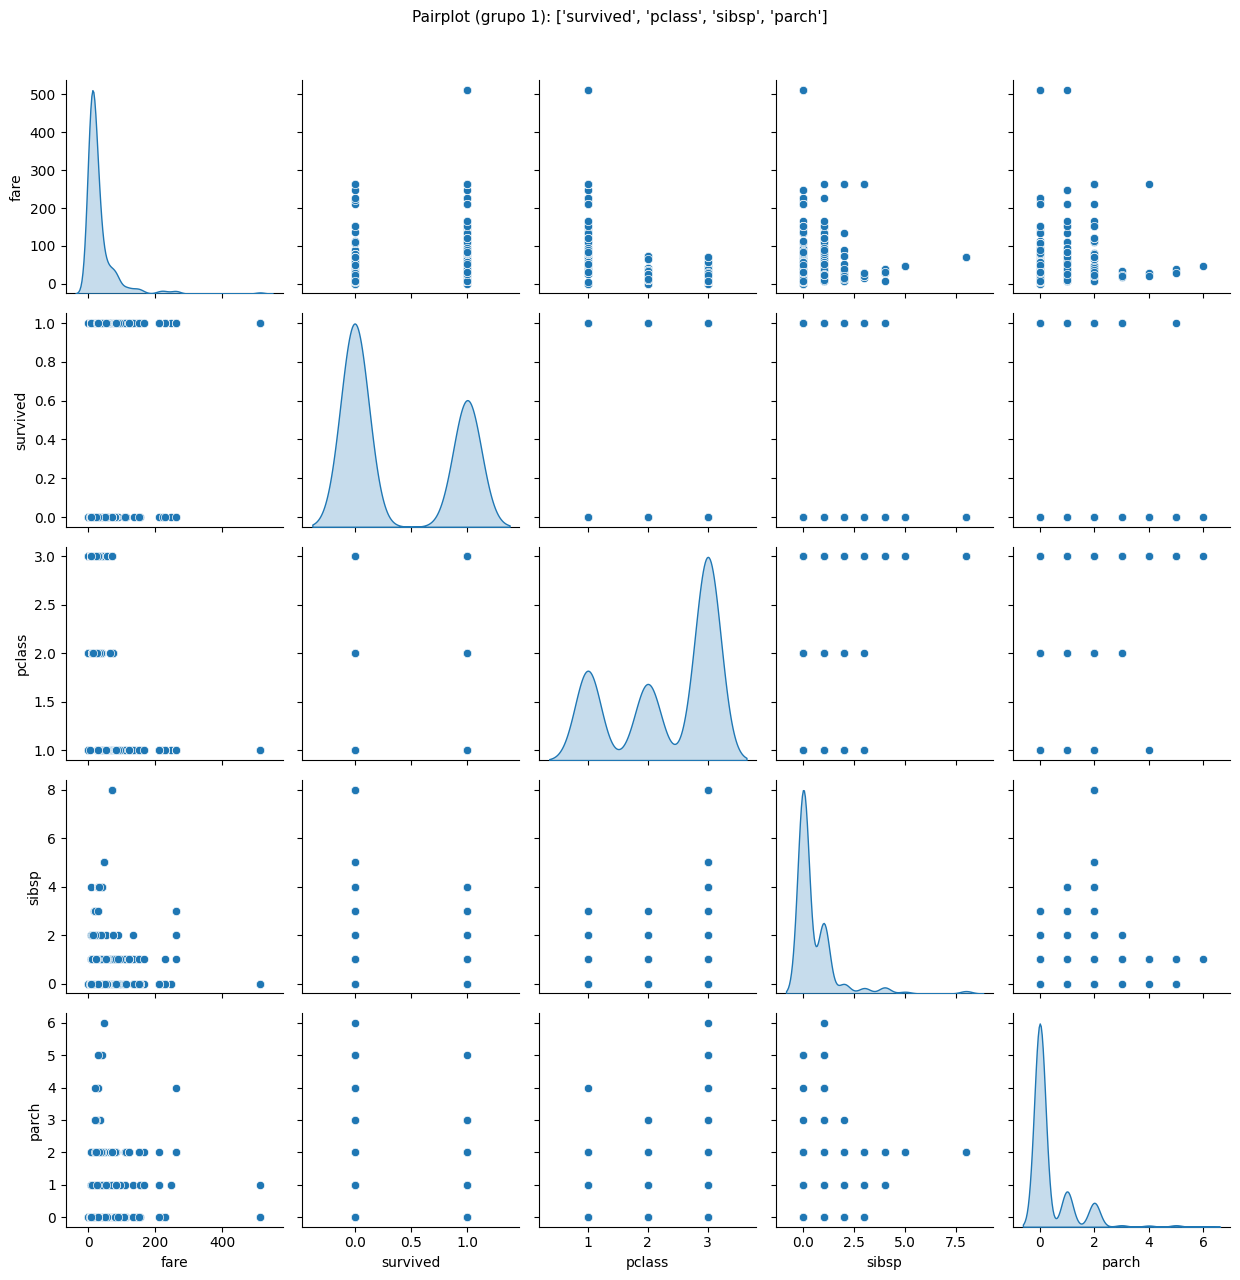

Features visualizadas: ['survived', 'pclass', 'sibsp', 'parch']


In [12]:
features_plot = plot_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.1,
)

print("Features visualizadas:", features_plot)

### 3.2 Pasando columnas específicas con `columns`

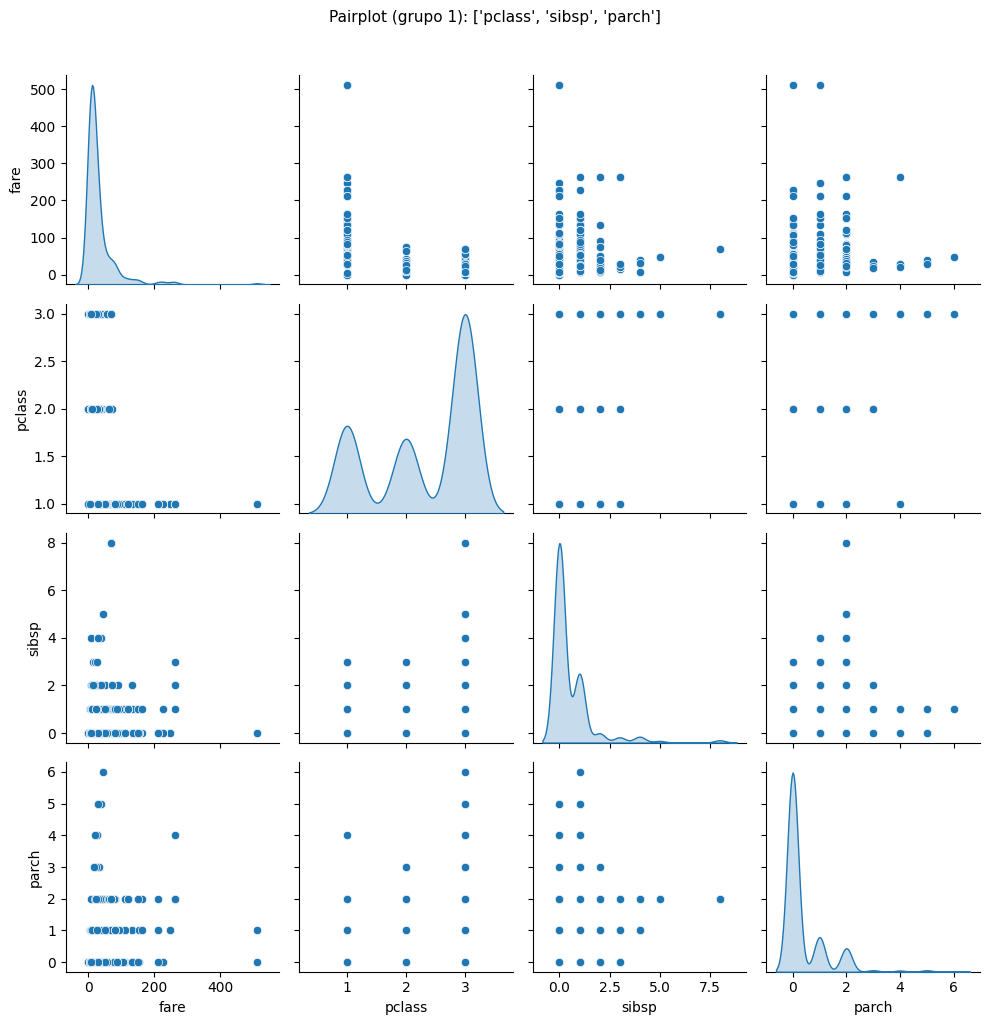

Features visualizadas: ['pclass', 'sibsp', 'parch']


In [20]:
features_custom = plot_features_num_regression(
    df=df,
    target_col="fare",
    columns=["pclass", "age", "sibsp", "parch"],
    umbral_corr=0.1,
)

print("Features visualizadas:", features_custom)

### 3.3 Con filtro de p-valor

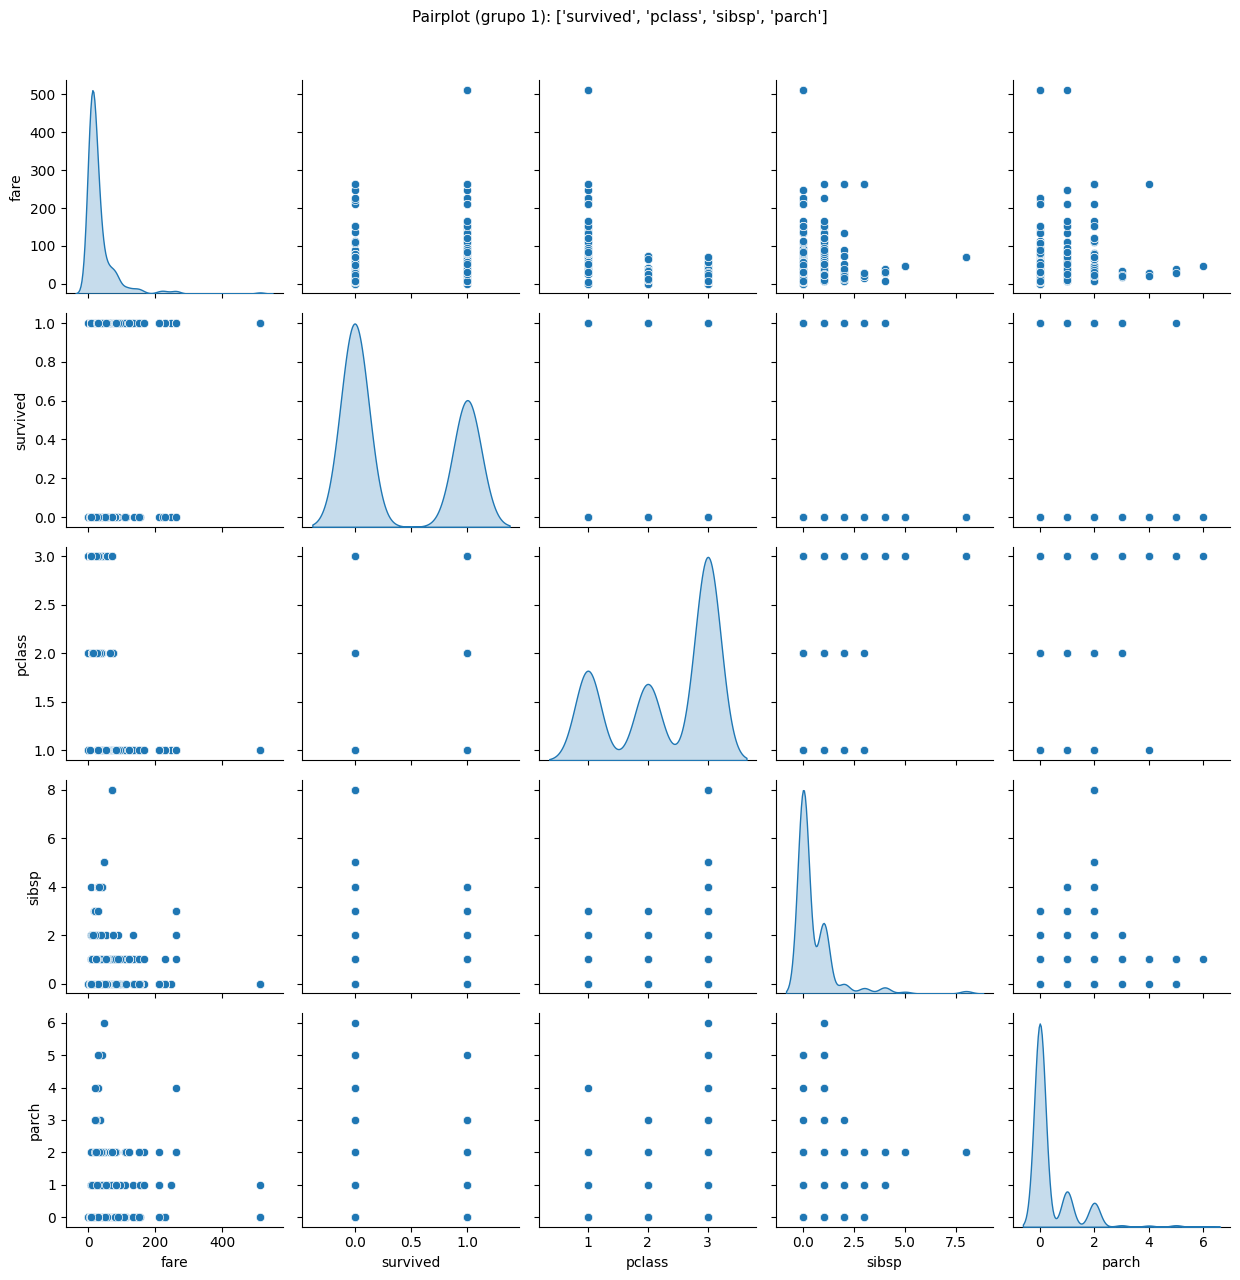

Features visualizadas: ['survived', 'pclass', 'sibsp', 'parch']


In [14]:
features_plot_pval = plot_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.1,
    pvalue=0.05,
)

print("Features visualizadas:", features_plot_pval)

### 3.4 Umbral muy alto — ninguna feature cumple los criterios

In [15]:
features_vacio = plot_features_num_regression(
    df=df,
    target_col="fare",
    umbral_corr=0.99,
)

print("Features visualizadas:", features_vacio)

No se encontraron columnas que cumplan los criterios especificados.
Features visualizadas: []


### 3.5 Casos de error — comprobación de validaciones

In [16]:
# target_col vacío
plot_features_num_regression(
    df=df,
    target_col="",
)

Error: 'target_col' debe ser un string no vacío.


In [17]:
# columna en 'columns' que no existe
plot_features_num_regression(
    df=df,
    target_col="fare",
    columns=["columna_inventada"],
)

Error: las siguientes columnas no existen en el DataFrame: ['columna_inventada']


In [18]:
# columna en 'columns' que no es numérica
plot_features_num_regression(
    df=df,
    target_col="fare",
    columns=["sex"],
)

Error: las siguientes columnas no son numéricas: ['sex']


---
## 4. Resumen

| Función | Entrada | Salida |
|---|---|---|
| `get_features_num_regression` | df, target_col, umbral_corr, pvalue | Lista de features numéricas correlacionadas |
| `plot_features_num_regression` | df, target_col, columns, umbral_corr, pvalue | Lista de features + pairplots |

**Criterios de selección:**
- `|correlación de Pearson| > umbral_corr`
- Si se especifica `pvalue`: p-valor del test < pvalue

**Valores de retorno especiales:**
- `None` → error en los parámetros de entrada
- `[]` → ninguna feature supera los criterios indicados
- `list` → features que cumplen los criterios